## 模拟退火（SA）

模拟退火是一种循环算法。 

1. 我们先设定一个初始的温度T (这个温度会比较高,比如2000) 
2. 每次循环都退火一次。（具体怎么操作后面详解）
3. 然后降低T的温度,我们通过让T和一个"降温系数"α (一个接近1的小数,比如0.99)相乘,达到慢慢降低温度的效果,直到接近于 0（我们用eps来代表一个接近0的数（比如0.00001），只要T < eps就可以退出循环了）



## 问题定义

假设我们面临一个组合优化问题，其模型可以通过以下三元组描述：

$$(S, E, N)$$

其中，

- 解空间 $S$ ：所有可行解的集合。

- 能量函数 (Energy Function) $E: S \rightarrow \mathbb{R}$ ：也称为目标函数。对于每一个解 $x \in S$ ，都有一个对应的标量值 $E(x)$ 。我们的目标是寻找全局最小解 $x^*$ ，使得：

$$\forall x \in S, \quad E(x^*) \leq E(x)$$

- 邻域结构 $N$：对于任意状态 $x$ ，存在一个邻域 $N(x) \subseteq S$ 。算法通过在 $N(x)$ 中进行扰动来产生新的候选解。

## 核心机制

模拟退火的核心在于，如何决定一个新的候选解。不同于贪心算法只接受更优解，SA以一定的概率接受劣解，从而具备跳出局部最优的能力。

假设当前状态为 $x_{old}$ ，能量为 $E(x_{old})$ ，我们通过邻域函数产生一个新的状态 $x_{new}$ ，能量为 $E(x_{new})$ 。

能量差为： $$\Delta E = E(x_{new}) - E(x_{old})$$ 

状态转移概率 $P(x_{old} \rightarrow x_{new})$ 定义如下：

$$P = \begin{cases} 
1 & \text{if } \Delta E < 0 \quad (\text{接受更优解}) \\
e^{-\frac{\Delta E}{T}} & \text{if } \Delta E \geq 0 \quad (\text{以概率接受劣解})
\end{cases}$$

其中：$\Delta E > 0$ 表示新解比旧解“差”（能量更高）。$T$ 是控制参数，称为温度 (Temperature)。

当 $\Delta E > 0$ 时，接受概率 $P = \exp(-\frac{\Delta E}{T})$。

若 $T$ 很大（高温），$ \frac{\Delta E}{T} \approx 0 $，则 $P \approx 1$。此时算法表现为随机游走 (Random Walk)，几乎接受所有移动，具有极强的全局搜索能力。

若 $T$ 很小（低温），$ \frac{\Delta E}{T} \gg 0 $，则 $P \approx 0$。此时算法趋向于贪心算法，只接受更优解，进行精细的局部搜索。

 Geman (1984) 从理论上证明了：如果温度下降得足够慢（例如满足对数冷却进度 $T_k \geq \frac{c}{\ln(1+k)}$），且每一温度下的迭代足够长，模拟退火算法以概率 1 收敛于全局最优解。


## 人话

假设你看不懂上面的文字，请看以下的说明。

想象一下，你被蒙着眼空投到了一个连绵起伏的山脉中。你的目标是找到整个山脉的最低点（全局最优解）。

如果你只允许“往低处走”，那你很快就会掉进最近的一个小坑（局部最优解）里。因为四周都是上坡路，你出不去了。但这可能只是一个离山顶很近的小水坑，真正的深谷（全局最优）在另一座山翻过去之后。

为了不被困在小坑里，模拟退火给了你一瓶“烈酒”（温度 $T$ ）。你喝得酩酊大醉。虽然你的本能是往低处走，但因为醉得厉害，你有很大的概率会胡乱走，甚至摇摇晃晃地爬上高坡（接受更差的解）。

Belike:

![](image-3.png)

过程中（降温阶段）, 酒劲慢慢消退。你变得清醒了一些，虽然偶尔还会发疯往上坡走两步，但大多数时候你更愿意往低处走。

最后（低温阶段），你彻底酒醒了。这时候你变得非常谨慎，只往低处走，坚决不往上爬。这时候你基本上就在一个很深的山谷底徘徊，做最后的微调。


为什么这很重要？ 正是因为这通胡乱爬坡，让你有机会翻越眼前的小山脊，跳出那个小坑。




你可能会疑惑，为什么我们要用 $P = e^{-\frac{\Delta E}{T}}$ 这个看上去这么奇怪的概率去控制接受劣解的概率？

直观上来看，你可以把ΔE看作是你要付出的代价，把T看作你的承受能力。

如果我们令$P = 1 - k \cdot \Delta E$, 那么我为了某个角色的皮肤需要氪金6元，我的不爽程度是10；假设这个皮肤需要的是600元，我的不爽程度是10.

但现实是，6块钱没准我一眨眼就付过去了（概率 $\approx 1$ ），60块钱我就得想想这个皮肤到底值不值，但是这个皮肤要是卖600块钱，我拒绝的意愿就不是增加10倍，而是断崖式下跌，接受概率≈0了。我不仅拒绝，我还去官方评论区骂。

指数函数 $e^{-x}$ 完美模拟了人类（以及自然界）对“代价”的敏感度：小代价ΔE，带入到公式中，概率几乎是1，几乎没什么感觉；大代价ΔE的概率会迅速衰减为0，拒绝接受新解。

这种对小错误宽容，对大错误严厉的非线性机制，能保证算法在局部微调时非常灵活，但绝不会荒唐地跳到一个极差的解。

在数学层面，选择指数是因为它能同时满足概率的惩罚特性和能量的加法特性。

独立事件的概率是相乘的： 如果我要连续走两步，总概率是 $P_{total} = P_1 \times P_2$ ；能量（代价）是相加的： 走两步的总代价是 $E_{total} = E_1 + E_2$。

只有指数函数能把“加法”变成“乘法”：$e^{-(E_1 + E_2)} = e^{-E_1} \times e^{-E_2}$ ，这意味着：一系列微小的变坏（能量累加），在概率上等同于一次大的变坏（概率累乘）。 这种数学上的一致性，保证了算法无论是一步到位还是分步走，其统计特性是稳定的。

此外，为了保证算法最终能收敛到全局最优（也就是达到平稳分布），马尔可夫链必须满足细致平衡方程：$$P(A) \cdot T(A \to B) = P(B) \cdot T(B \to A)$$

其中 $P(A)$ 是系统处于状态 A 的概率。

在统计力学中，状态 A 的概率 $P(A)$ 服从 Boltzmann 分布：$P(A) \propto e^{-E(A)/T}$。
代入推导后，只有当转移概率满足 Metropolis 准则（即包含指数项）时，这个等式才成立。如果不用 $e$，而是用其他函数（比如线性或多项式），马尔可夫链破坏了物理平衡，算法最终可能就会在一个错误的分布上打转，永远无法收敛到真正的全局最优。

最后，在物理世界中，一个热力学系统（比如一壶热水或者一块烧红的铁）中，并不是所有分子的能量都是一样的。它们服从 Boltzmann 分布。

其中 $$N_i \propto e^{-\frac{E_i}{kT}}$$ 

$N_i$：处于能量 $E_i$ 的分子数量。$k$：玻尔兹曼常数。$T$：温度。

这个公式的意思是说，即便在很低的温度下，依然会有极少数分子拥有非常高的能量（处于高能级）。正是这微小的概率，使得晶体在冷却过程中能调整内部结构，消除缺陷。使用 $P = e^{-\frac{\Delta E}{T}}$ 不是算法设计者拍脑袋想出来的，而是直接抄袭了“退火”这个机制的底层逻辑。我们在计算机里模拟了大自然的冷却过程，因为大自然通过这种方式极其完美地找到了能量最低的晶体结构（全局最优解）。

记得安装：

```pip install scikit-op```

例如，求解该函数的最优值：
```bash
demo_func = lambda x: x[0] ** 2 + (x[1] - 0.05) ** 2 + x[2] ** 2
```

In [8]:
demo_func = lambda x: x[0] ** 2 + (x[1] - 0.05) ** 2 + x[2] ** 2

best_x: [ 1.64372305e-05  4.99911243e-02 -1.24782340e-05] best_y 5.046674045935606e-10


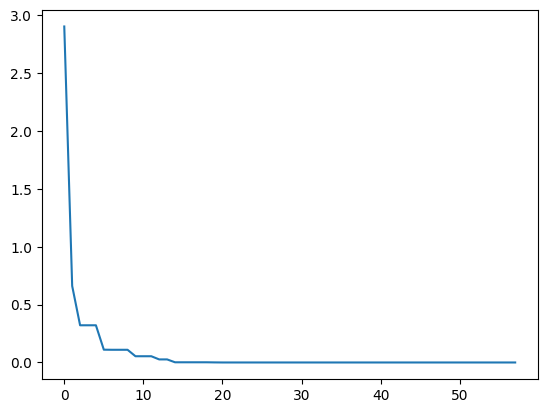

In [ ]:
from sko.SA import SA
import matplotlib.pyplot as plt
import pandas as pd

sa = SA(func=demo_func, x0=[1, 1, 1], T_max=1, T_min=1e-9, L=300, max_stay_counter=150)
best_x, best_y = sa.run()
print('best_x:', best_x, 'best_y', best_y)

plt.plot(pd.DataFrame(sa.best_y_history).cummin(axis=0))
plt.show()

### 尝试使用SA解决旅行商问题





正在计算最优路径...
搜索完成
最短路径长度: 401.30
最佳访问顺序: [ 3 18 11  0  1 19  8  6 10 15  9 14  4 13  5 12 16  7  2 17]


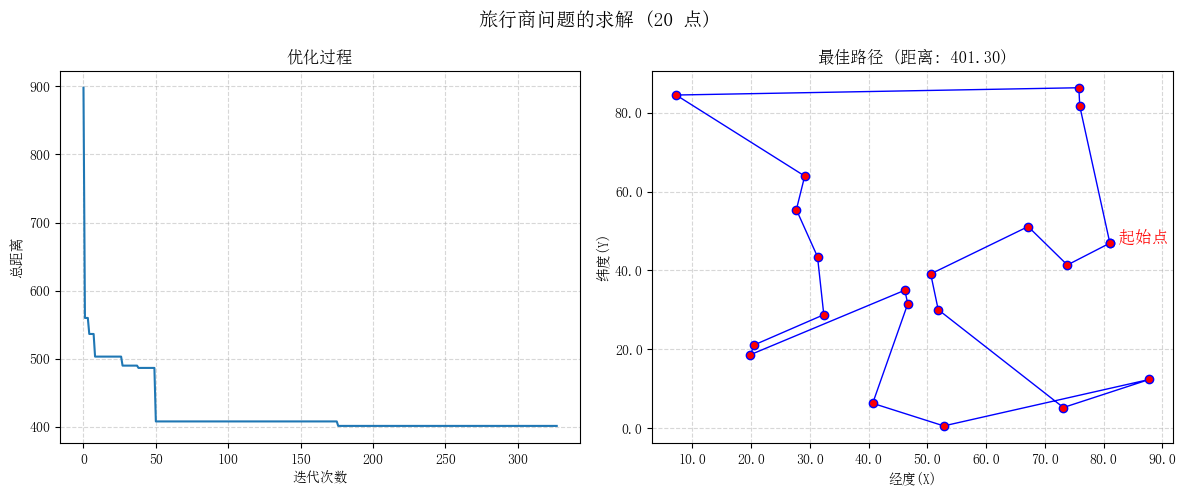

In [28]:
import numpy as np
from scipy import spatial
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from sko.SA import SA_TSP
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimSun'] 
plt.rcParams['axes.unicode_minus'] = False

num_points = 20
points_coordinate = np.random.rand(num_points, 2) *90
distance_matrix = spatial.distance.cdist(points_coordinate, points_coordinate, metric='euclidean')

def cal_total_distance(routine):
    '''
    目标函数 (Objective Function): 计算路径的总长度
    Input: routine (一个包含访问顺序的索引列表，如 [0, 5, 2, ...])
    Output: total_distance (浮点数)
    '''
    num_points, = routine.shape
    # 累加当前点到下一点的距离
    # 使用 % 运算是为了让最后一个点连回第一个点 (闭环)
    return sum([distance_matrix[routine[i % num_points], routine[(i + 1) % num_points]] for i in range(num_points)])

print("正在计算最优路径...")

# 参数说明：
# func:  目标函数（越小越好）
# x0:    初始解（这里是一个随机的 0 到 num_points-1 的排列）
# T_max: 初始温度（越高越容易接受差解，跳出局部最优）
# T_min: 终止温度
# L:     每个温度下的迭代次数（链长）
sa_tsp = SA_TSP(func=cal_total_distance, x0=range(num_points), T_max=100, T_min=1, L=10 * num_points)

best_points, best_distance = sa_tsp.run()

print(f"搜索完成\n最短路径长度: {best_distance:.2f}")
print(f"最佳访问顺序: {best_points}")



fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'旅行商问题的求解 ({num_points} 点)', fontsize=14)

ax[0].plot(sa_tsp.best_y_history)
ax[0].set_xlabel("迭代次数")
ax[0].set_ylabel("总距离")
ax[0].set_title("优化过程")
ax[0].grid(True, linestyle='--', alpha=0.5)




best_points_ = np.concatenate([best_points, [best_points[0]]])
best_points_coordinate = points_coordinate[best_points_, :]

ax[1].plot(best_points_coordinate[:, 0], best_points_coordinate[:, 1],
           marker='o', markerfacecolor='red', color='blue', linestyle='-', linewidth=1, markersize=6)

# 标注起点
ax[1].text(best_points_coordinate[0, 0], best_points_coordinate[0, 1], ' 起始点', color='red', fontsize=12, fontweight='bold')

ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax[1].set_xlabel("经度(X)")
ax[1].set_ylabel("纬度(Y)")
ax[1].set_title(f"最佳路径 (距离: {best_distance:.2f})")
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()